# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [ ]:
import os
import sys
from pprint import pprint

# so that mllm_shap can be imported without installing the package
sys.path.insert(0, os.path.abspath("../mllm_shap/src"))

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"
os.environ["LOG_LEVEL"] = "INFO"

In [3]:
import numpy as np
import pandas as pd
import torch

np.random.seed(42)

device = (
    torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


In [ ]:
from mllm_shap.connectors import LiquidAudio, ModelConfig
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter
from mllm_shap.shap import Explainer, McShapExplainer
from mllm_shap.shap.embeddings import MeanReducer
from mllm_shap.shap.enums import Mode
from mllm_shap.shap.normalizers import AbsSumNormalizer
from mllm_shap.shap.similarity import TfIdfCosineSimilarity
from mllm_shap.utils.audio import display_audio
from mllm_shap.utils.jupyter import (
    display_shap_colors_df,
    display_shap_colors_df_audio,
    plot_distribution,
)

# Usage

Lets take some sample data from experiments directory (not uploaded to repo, available on huggingface).

In [ ]:
df = pd.read_parquet("../experiments/data/voicebench/single_sentence.parquet")
sample_entry = df.sample(1).iloc[0].to_dict()
del df

pprint(sample_entry)
display_audio(sample_entry["audio__male"][0])

Define LiquidAudio model (this call loads it up to the memory!).

Create compact explainer that will make initial call and then explain it using Shapley Values approximated using Monte Carlo. Set minimal number of samples for demo purpose, that is only first-order omission ones (where only one token at the time is hidden) and empty sample (if it is not "globally" empty, that is when expandability is not performed on all tokens).

AbsSumNormalizer divides each value by sum of abs shapley values.

In [ ]:
model = LiquidAudio(
    device=device, history_tracking_mode=ModelHistoryTrackingMode.AUDIO
)  # track and generate only audio history
shap = McShapExplainer(
    num_samples=-1,
    mode=Mode.CONTEXTUAL,  # use contextual embeddings, default
    # use mean pooling to reduce token embeddings to single embedding per audio, default
    embedding_reducer=MeanReducer(),
    similarity_measure=TfIdfCosineSimilarity(),  # use TF-IDF weighted cosine similarity to compare embeddings
    normalizer=AbsSumNormalizer(),  # use abs sum normalizer to normalize shap values
)
explainer = Explainer(model=model, shap_explainer=shap)

W1021 22:03:18.715000 1875 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Create new chat that treats Assistant messages as system, that is will ignore them for shapley values calculation - they will be feed to each prompt as system messages. This significantly reduces number of requests needed for multi turn expandability, yet might not be possible due to business requirements. 

To further reduce number of calls we exclude punctuation tokens.

In [7]:
chat = model.get_new_chat(
    system_roles_setup=SystemRolesSetup.SYSTEM,  # explain assistant responses as well
    token_filter=ExcludePunctuationTokensFilter(),  # exclude punctuation tokens from shapley values calculation
)

chat.new_turn(Role.USER)
chat.add_text("Who is speaking in the audio?")
chat.add_audio(sample_entry["audio__male"][0])
chat.end_turn()

Let's have a look at chat representation:

In [8]:
pprint(chat.get_conversation())

[[ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 0, 0, 0], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?', shap_values=None),
  ChatEntry(content_type=1, roles=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], content='Audio bytes of total length 0', shap_values=None),
  ChatEntry(content_type=0, roles=[2, 2], content='<|im_end|>, \n', shap_values=None)]]


Representation is a list of list of ConversationEntry - so it can be accessed as  chat.get_conversation()[turn_number][message_number].{field}

Let's calculate shapley values for current conversation.

Verbose=False saves memory. Generation kwargs allows to customize model interference - here we limit it to 32 tokens and change text_temperature from default 0.0 to 0.2. 

In [9]:
generation_kwargs = {
    "max_new_tokens": 32,
    "model_config": ModelConfig(text_temperature=0.2),
}

result = explainer(
    chat=chat,
    verbose=True,
    generation_kwargs=generation_kwargs,
    progress_bar=True,  # show progress bar during generation, default
)

2025-10-21 22:03:25,274 - audio_shap.shap.compact - INFO - Generating full response from the model...
2025-10-21 22:03:28,398 - audio_shap.shap._base.explainer - INFO - Number of tokens for explainability: 61, (up to 2305843009213693951 additional calls)


Calculating SHAP values:   0%|          | 0/62 [00:00<?, ?it/s]

Result has now following fields available:

- full_chat - chat with base response (generated based on whole entry) with set cache and calculated shapley values
- source_chat - original chat feed to the explainer
- history - history of all chats used

In [10]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 0, 0, 0], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?', shap_values=[nan, nan, nan, 0.01434326171875, 0.01104736328125, 0.01239013671875, 0.013671875, 0.01239013671875, 0.013671875, nan]),
  ChatEntry(content_type=1, roles=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], content='Audio bytes of total length 0', shap_values=[0.017578125, 0.017578125, 0.0162353515625, 0.0169677734375, 0.0162353515625, 0.0162353515625, 0.017578125, 0.0162353515625, 0.0169677734375, 0.0162353515625, 0.0162353515625, 0.0169677734375, 0.017578125, 0.0162353515625, 0.0162353515625, 0.017578125, 0.017578125, 0.017578125, 0.017578125, 0.017578125, 0.017578125, 0.0169677734375, 0.0162353515625, 0.0162353515625, 0.0162353515625, 0.0162353515625, 0.0162353515625, 0.0162353515625, 0.017578125, 0.017578125, 0.01623

In [11]:
explained_chat_conversation[1][1].display()

BY: ASSISTANT
AUDIO CONTENT:


Encoding audio tokens in seperation creates weird non-continual audio description.

Model was set to return just text tokens, so chat history has only text tokens. We can see that in the json representation inside ConversationEntry shap_values field is now populated. Nan values indicated that this token wasn't taken into calculation scope. As expected, we have 3 not-nan tokens. Let's see them.

In [12]:
user_entry = explained_chat_conversation[0][0]

display_shap_colors_df(
    pd.DataFrame(
        list(zip(user_entry.content, user_entry.shap_values)),
        columns=["Token", "Shapley Value"],
    )
)

,Token,Shapley Value
0,<|im_start|>,nan
1,user,nan
2,,nan
3,Who,0.014343
4,is,0.011047
5,speaking,0.012390
6,in,0.013672
7,the,0.012390
8,audio,0.013672
9,?,nan


In [13]:
audio_to_explain = explained_chat_conversation[0][1]

display_shap_colors_df_audio(
    pd.DataFrame(
        list(zip(audio_to_explain.content, audio_to_explain.shap_values)),
        columns=["Audio", "Shapley Value"],
    )
)

,Audio,Shapley Value
0,Your browser does not support the audio element.,0.017578
1,Your browser does not support the audio element.,0.017578
2,Your browser does not support the audio element.,0.016235
3,Your browser does not support the audio element.,0.016968
4,Your browser does not support the audio element.,0.016235
5,Your browser does not support the audio element.,0.016235
6,Your browser does not support the audio element.,0.017578
7,Your browser does not support the audio element.,0.016235
8,Your browser does not support the audio element.,0.016968
9,Your browser does not support the audio element.,0.016235


Let's create another turn to see how input significance will change (it is a very dummy audio just for a showcase - now we have text, audio in, audio out and multi turn expandability task):

In [14]:
explained_chat.new_turn(Role.USER)
explained_chat.add_audio(sample_entry["audio__female"][0])
explained_chat.end_turn()

And again, let's explain it:

In [15]:
result = explainer(
    chat=explained_chat, verbose=False, generation_kwargs=generation_kwargs
)

2025-10-21 22:06:14,057 - audio_shap.shap.compact - INFO - Generating full response from the model...
2025-10-21 22:06:19,334 - audio_shap.shap._base.explainer - INFO - Number of tokens for explainability: 139, (up to 696898287454081973172991196020261297061887 additional calls)
2025-10-21 22:06:22,224 - audio_shap.shap._base.explainer - INFO - Deduplicated 0/140 masks using existing cache.


Calculating SHAP values:   0%|          | 0/140 [00:00<?, ?it/s]

In [ ]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 0, 0, 0], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?', shap_values=[nan, nan, nan, 0.0037384033203125, 0.007476806640625, 0.0042724609375, 0.008544921875, 0.0101318359375, 0.00909423828125, nan]),
  ChatEntry(content_type=1, roles=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], content='Audio bytes of total length 0', shap_values=[0.008544921875, 0.00799560546875, 0.008544921875, 0.007476806640625, 0.00799560546875, 0.008544921875, 0.0096435546875, 0.008544921875, 0.008544921875, 0.007476806640625, 0.008544921875, 0.008544921875, 0.008544921875, 0.008544921875, 0.007476806640625, 0.007476806640625, 0.0096435546875, 0.0096435546875, 0.008544921875, 0.008544921875, 0.0096435546875, 0.00799560546875, 0.007476806640625, 0.0096435546875, 0.0096435546875, 0.0096435546875, 0.0096435546875,

We can now easily plot their distribution. Don't pay attention to their irrelevance, this example is is very poorly approximated.

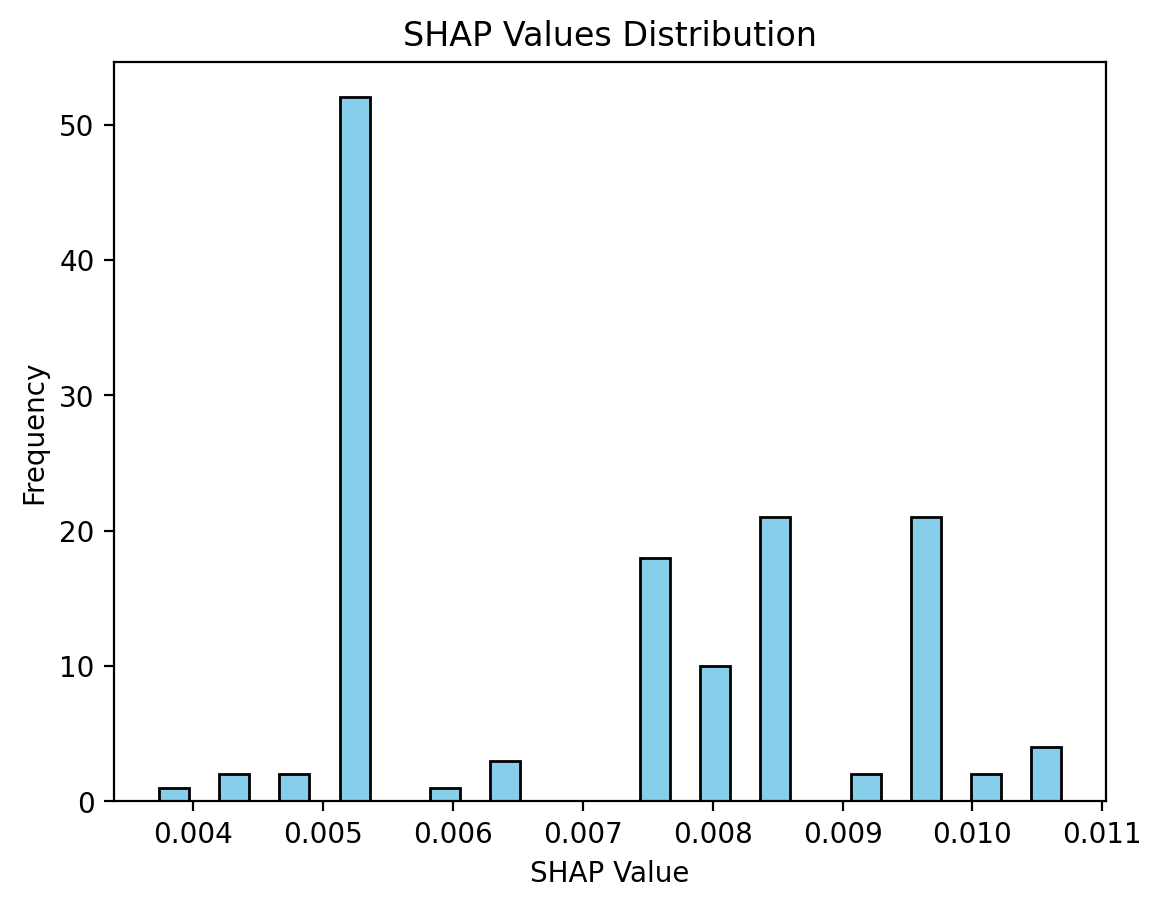

In [ ]:
sv = explained_chat.shap.normalized_values

sv = sv[~torch.isnan(sv)]

plot_distribution(sv, bins=30, color="skyblue", edgecolor="black")